# Medical Cost Classification using Machine Learning
**Objective:** Convert the continuous `charges` target into a binary class (Low / High Medical Cost) using the **median** as the threshold, then train and compare **5 classification algorithms**.

**Algorithms:** Logistic Regression, Decision Tree, KNN, SVM, Naive Bayes

**Note:** The original dataset is a *regression* problem (`charges` is continuous). It is converted to binary classification **only** to satisfy the assignment requirement of using five classifiers.

## Step 1 - Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2 - Load the Dataset
Change `FILE_PATH` to the location of your CSV file.

In [2]:
FILE_PATH = "medical_cost.csv"      # <-- change to your file name / full path

df = pd.read_csv(FILE_PATH)

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (5000, 7)


,age,sex,bmi,children,smoker,region,charges
0,56,male,29.1,0,no,northwest,19520.04
1,46,female,27.0,1,no,southwest,23144.05
2,32,male,39.5,0,no,southeast,19394.29
3,60,male,26.2,3,no,southeast,18765.13
4,25,male,24.2,3,no,northeast,21360.81


## Step 3 - Inspect the Data

In [3]:
print("--- Info ---")
df.info()

print("\n--- Missing values per column ---")
print(df.isnull().sum())

print("\n--- Duplicate rows ---")
print("Duplicates found:", df.duplicated().sum())

print("\n--- Statistical summary ---")
display(df.describe())

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5000 non-null   int64  
 1   sex       5000 non-null   object 
 2   bmi       5000 non-null   float64
 3   children  5000 non-null   int64  
 4   smoker    5000 non-null   object 
 5   region    5000 non-null   object 
 6   charges   5000 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 273.6+ KB

--- Missing values per column ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- Duplicate rows ---
Duplicates found: 0

--- Statistical summary ---


,age,bmi,children,charges
count,5000.00000,5000.000000,5000.000000,5000.000000
mean,41.16820,30.467340,1.488800,25522.335752
std,13.53105,6.148115,1.464071,10822.530877
min,18.00000,15.000000,0.000000,1120.000000
25%,29.00000,26.300000,0.000000,18093.170000
50%,41.00000,30.400000,1.000000,22719.775000
75%,53.00000,34.700000,2.000000,29058.630000
max,64.00000,52.000000,5.000000,60568.260000


In [4]:
# Remove duplicates if any (keeps the analysis clean)
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Rows before: {before} | Rows after removing duplicates: {df.shape[0]}")

# Handle missing values (only runs if any exist)
if df.isnull().sum().sum() > 0:
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype == 'object':
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna(df[col].median())
    print("Missing values filled.")
else:
    print("No missing values to handle.")

Rows before: 5000 | Rows after removing duplicates: 5000
No missing values to handle.


## Step 4 & 5 - Create the Binary Target `cost_class`
`charges <= median` -> **0 (Low Cost)**  |  `charges > median` -> **1 (High Cost)**

In [5]:
TARGET_COL = "charges"     # change if your column has a different name

median_charge = df[TARGET_COL].median()
print(f"Median {TARGET_COL}: {median_charge:.2f}")

df["cost_class"] = (df[TARGET_COL] > median_charge).astype(int)

print("\nClass distribution:")
print(df["cost_class"].value_counts().rename({0: "Low Cost (0)", 1: "High Cost (1)"}))
print("\nClass balance (%):")
print((df["cost_class"].value_counts(normalize=True) * 100).round(2))

Median charges: 22719.78

Class distribution:
cost_class
Low Cost (0)     2500
High Cost (1)    2500
Name: count, dtype: int64

Class balance (%):
cost_class
0    50.0
1    50.0
Name: proportion, dtype: float64


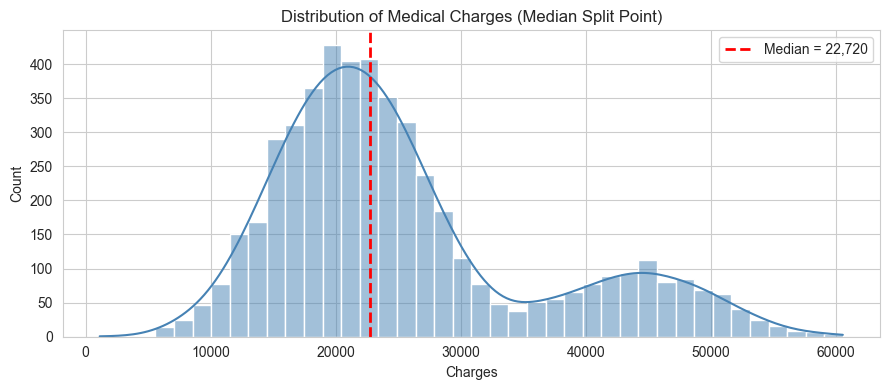

In [6]:
# Quick visual: distribution of charges with the median split line
plt.figure(figsize=(9, 4))
sns.histplot(df[TARGET_COL], bins=40, kde=True, color="steelblue")
plt.axvline(median_charge, color="red", linestyle="--", linewidth=2,
            label=f"Median = {median_charge:,.0f}")
plt.title("Distribution of Medical Charges (Median Split Point)")
plt.xlabel("Charges")
plt.legend()
plt.tight_layout()
plt.show()

## Step 6 & 7 - Build Feature Matrix X and Encode Categoricals
`charges` is **dropped** from X to avoid target leakage.

In [11]:
# y = target, X = all features EXCEPT charges and cost_class
y = df["cost_class"]
X = df.drop(columns=[TARGET_COL, "cost_class"])

# Drop any index-like column if present
for junk in ["Unnamed: 0", "id", "ID", "index"]:
    if junk in X.columns:
        X = X.drop(columns=[junk])

print("Feature columns before encoding:", list(X.columns))

cat_cols = X.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", cat_cols)

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("\nFeature columns after encoding:", list(X.columns))
print("Final X shape:", X.shape, "| y shape:", y.shape)
X.head()

Feature columns before encoding: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Categorical columns to encode: ['sex', 'smoker', 'region']

Feature columns after encoding: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
Final X shape: (5000, 8) | y shape: (5000,)


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,56,29.1,0,True,False,True,False,False
1,46,27.0,1,False,False,False,False,True
2,32,39.5,0,True,False,False,True,False
3,60,26.2,3,True,False,False,True,False
4,25,24.2,3,True,False,False,False,False


## Step 8 - Train / Test Split (80 / 20)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training set:", X_train.shape[0], "rows")
print("Testing set :", X_test.shape[0], "rows")
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(3))

Training set: 4000 rows
Testing set : 1000 rows

Train class balance:
 cost_class
1    0.5
0    0.5
Name: proportion, dtype: float64

Test class balance:
 cost_class
0    0.5
1    0.5
Name: proportion, dtype: float64


## Step 9 - Feature Scaling
Required for Logistic Regression, KNN and SVM (distance / margin based). The scaler is fitted on the **training set only**.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")
print("Scaled training data shape:", X_train_scaled.shape)

Scaling complete.
Scaled training data shape: (4000, 8)


## Step 10 & 11 - Train All Five Models and Record Accuracy + Training Time

In [14]:
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    "Decision Tree":       (DecisionTreeClassifier(random_state=RANDOM_STATE), False),
    "KNN":                 (KNeighborsClassifier(n_neighbors=5), True),
    "SVM":                 (SVC(kernel="rbf", random_state=RANDOM_STATE), True),
    "Naive Bayes":         (GaussianNB(), False),
}
# The boolean flag = "needs scaled data"

results = []
trained = {}
predictions = {}

for name, (model, needs_scaling) in models.items():
    Xtr = X_train_scaled if needs_scaling else X_train
    Xte = X_test_scaled  if needs_scaling else X_test

    start = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - start

    y_pred = model.predict(Xte)

    results.append({
        "Algorithm": name,
        "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision (%)": round(precision_score(y_test, y_pred) * 100, 2),
        "Recall (%)": round(recall_score(y_test, y_pred) * 100, 2),
        "F1-score (%)": round(f1_score(y_test, y_pred) * 100, 2),
        "Training Time (sec)": round(train_time, 5),
    })
    trained[name] = model
    predictions[name] = y_pred
    print(f"{name:<22} trained in {train_time:.5f} s  |  Accuracy = {results[-1]['Accuracy (%)']}%")

Logistic Regression    trained in 0.07564 s  |  Accuracy = 81.0%
Decision Tree          trained in 0.02901 s  |  Accuracy = 74.0%
KNN                    trained in 0.01751 s  |  Accuracy = 78.2%
SVM                    trained in 0.37761 s  |  Accuracy = 81.2%
Naive Bayes            trained in 0.00274 s  |  Accuracy = 69.5%


## Step 12 - Accuracy Comparison Table (Section 8 of the notes)

In [15]:
results_df = pd.DataFrame(results)
results_df.index = range(1, len(results_df) + 1)
results_df.index.name = "S.No."

display(results_df)

best_model_name = results_df.loc[results_df["Accuracy (%)"].idxmax(), "Algorithm"]
fastest_model_name = results_df.loc[results_df["Training Time (sec)"].idxmin(), "Algorithm"]

print(f"\nHIGHEST ACCURACY : {best_model_name} "
      f"({results_df['Accuracy (%)'].max()}%)")
print(f"FASTEST TRAINING : {fastest_model_name} "
      f"({results_df['Training Time (sec)'].min()} sec)")

,Algorithm,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (sec)
S.No.,,,,,,
1,Logistic Regression,81.0,81.89,79.6,80.73,0.07564
2,Decision Tree,74.0,74.00,74.0,74.00,0.02901
3,KNN,78.2,78.89,77.0,77.94,0.01751
4,SVM,81.2,82.64,79.0,80.78,0.37761
5,Naive Bayes,69.5,100.00,39.0,56.12,0.00274



HIGHEST ACCURACY : SVM (81.2%)
FASTEST TRAINING : Naive Bayes (0.00274 sec)


In [16]:
# Save the results table for your report
results_df.to_csv("accuracy_comparison_table.csv")
print("Saved -> accuracy_comparison_table.csv")

Saved -> accuracy_comparison_table.csv


## Step 13 - Confusion Matrix for the Best Model

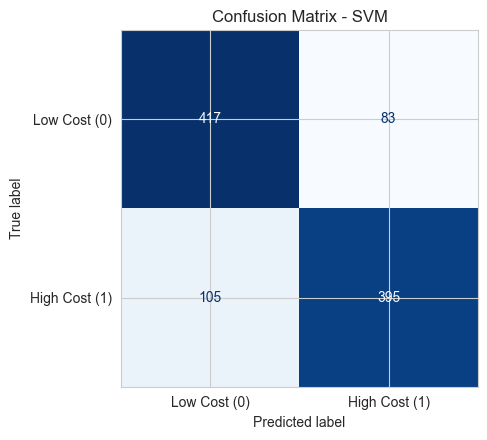

True Negative  (correct Low Cost) : 417
False Positive (Low predicted High): 83
False Negative (High predicted Low): 105
True Positive  (correct High Cost) : 395


In [17]:
best_pred = predictions[best_model_name]
cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Low Cost (0)", "High Cost (1)"])
disp.plot(cmap="Blues", ax=ax, values_format="d", colorbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (correct Low Cost) : {tn}")
print(f"False Positive (Low predicted High): {fp}")
print(f"False Negative (High predicted Low): {fn}")
print(f"True Positive  (correct High Cost) : {tp}")

## Step 14 - Accuracy Comparison Graph

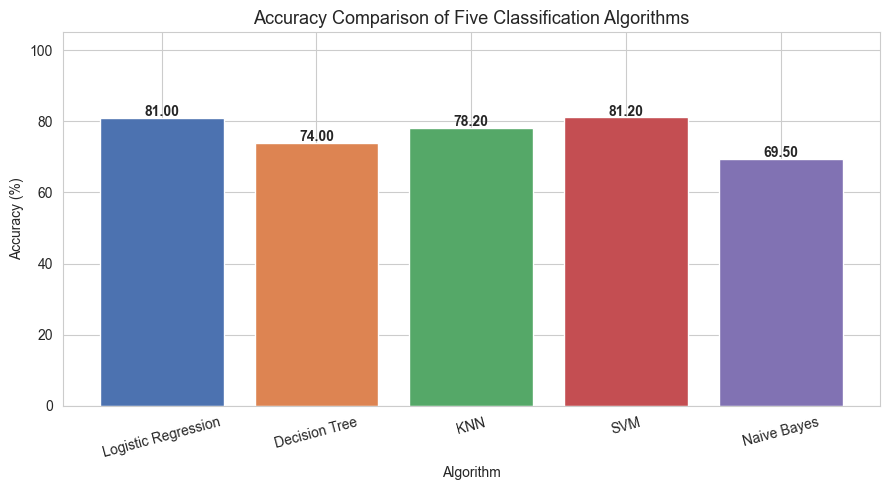

In [18]:
plt.figure(figsize=(9, 5))
bars = plt.bar(results_df["Algorithm"], results_df["Accuracy (%)"],
               color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"])

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.4, f"{h:.2f}",
             ha="center", fontsize=10, fontweight="bold")

plt.title("Accuracy Comparison of Five Classification Algorithms", fontsize=13)
plt.ylabel("Accuracy (%)")
plt.xlabel("Algorithm")
plt.ylim(0, 105)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=200)
plt.show()

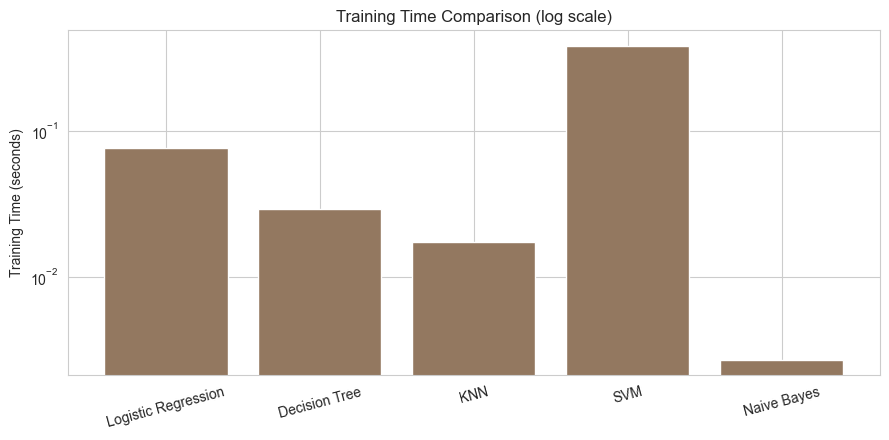

In [19]:
# Optional second graph: training time comparison (log scale, times are tiny)
plt.figure(figsize=(9, 4.5))
plt.bar(results_df["Algorithm"], results_df["Training Time (sec)"], color="#937860")
plt.yscale("log")
plt.title("Training Time Comparison (log scale)")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("training_time_comparison.png", dpi=200)
plt.show()

## Step 15 - Precision, Recall and F1-score (Classification Report)

In [20]:
print(f"CLASSIFICATION REPORT - {best_model_name}")
print("=" * 60)
print(classification_report(y_test, best_pred,
                            target_names=["Low Cost (0)", "High Cost (1)"],
                            digits=4))

CLASSIFICATION REPORT - SVM
               precision    recall  f1-score   support

 Low Cost (0)     0.7989    0.8340    0.8160       500
High Cost (1)     0.8264    0.7900    0.8078       500

     accuracy                         0.8120      1000
    macro avg     0.8126    0.8120    0.8119      1000
 weighted avg     0.8126    0.8120    0.8119      1000



In [21]:
# Full report for ALL five models (useful for the 2-page report)
for name in models:
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_test, predictions[name],
                                target_names=["Low Cost (0)", "High Cost (1)"],
                                digits=4))

Logistic Regression
               precision    recall  f1-score   support

 Low Cost (0)     0.8016    0.8240    0.8126       500
High Cost (1)     0.8189    0.7960    0.8073       500

     accuracy                         0.8100      1000
    macro avg     0.8102    0.8100    0.8100      1000
 weighted avg     0.8102    0.8100    0.8100      1000

Decision Tree
               precision    recall  f1-score   support

 Low Cost (0)     0.7400    0.7400    0.7400       500
High Cost (1)     0.7400    0.7400    0.7400       500

     accuracy                         0.7400      1000
    macro avg     0.7400    0.7400    0.7400      1000
 weighted avg     0.7400    0.7400    0.7400      1000

KNN
               precision    recall  f1-score   support

 Low Cost (0)     0.7754    0.7940    0.7846       500
High Cost (1)     0.7889    0.7700    0.7794       500

     accuracy                         0.7820      1000
    macro avg     0.7822    0.7820    0.7820      1000
 weighted avg     0

## Step 16 - Auto-Generated Facts for Q1-Q7
Use these **actual numbers** in your report. Do not use example values.

In [22]:
print("Q1. Which algorithm achieved the highest accuracy?")
print(f"    -> {best_model_name} with {results_df['Accuracy (%)'].max()}% test accuracy.\n")

print("Q2. Why did it perform best?")
print("    -> Write your explanation using the results below.")
print(results_df[["Algorithm", "Accuracy (%)", "F1-score (%)"]].to_string(index=False))
print()

print("Q3. Which algorithm trains fastest?")
print(f"    -> {fastest_model_name} at {results_df['Training Time (sec)'].min()} seconds.")
print(results_df[["Algorithm", "Training Time (sec)"]]
      .sort_values("Training Time (sec)").to_string(index=False))
print()

print(f"Dataset size used: {df.shape[0]} rows, {X.shape[1]} features after encoding.")
print(f"Median charge threshold: {median_charge:.2f}")
print(f"Train/Test split: {X_train.shape[0]} / {X_test.shape[0]} (80/20, stratified)")

Q1. Which algorithm achieved the highest accuracy?
    -> SVM with 81.2% test accuracy.

Q2. Why did it perform best?
    -> Write your explanation using the results below.
          Algorithm  Accuracy (%)  F1-score (%)
Logistic Regression          81.0         80.73
      Decision Tree          74.0         74.00
                KNN          78.2         77.94
                SVM          81.2         80.78
        Naive Bayes          69.5         56.12

Q3. Which algorithm trains fastest?
    -> Naive Bayes at 0.00274 seconds.
          Algorithm  Training Time (sec)
        Naive Bayes              0.00274
                KNN              0.01751
      Decision Tree              0.02901
Logistic Regression              0.07564
                SVM              0.37761

Dataset size used: 5000 rows, 8 features after encoding.
Median charge threshold: 22719.78
Train/Test split: 4000 / 1000 (80/20, stratified)


### Q4 - Q7 (written answers, no computation needed)

- **Q4. Small datasets?** SVM is effective on small/medium datasets because it maximises the margin and only depends on support vectors. Naive Bayes is also viable since it estimates few parameters.
- **Q5. Large datasets?** Logistic Regression is the strong scalable baseline (fast to train, low memory). Final choice still depends on data size, feature count and measured performance.
- **Q6. Evaluation metric?** Accuracy is the primary metric here because the median split produces balanced classes; it is supported by Precision, Recall, F1-score and the Confusion Matrix.
- **Q7. Industry recommendation?** Recommend the best model **only as a decision-support tool**, after further validation, fairness checks (age/sex/region bias), privacy review under health-data regulations, and testing on representative real-world data.

## Optional - Feature Importance (helps answer Q2)

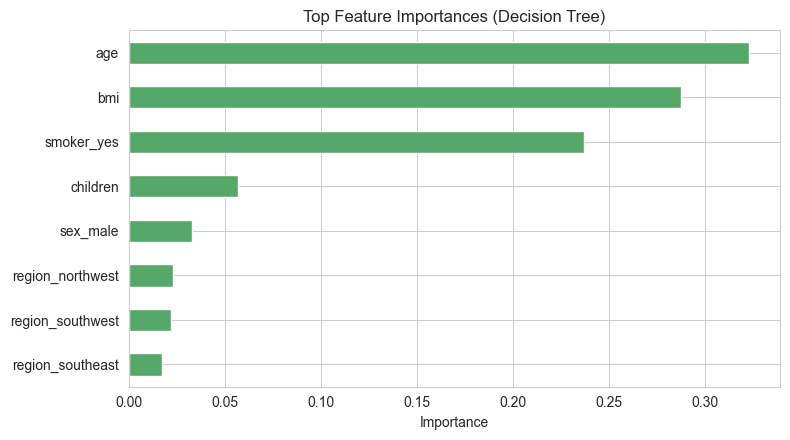

age                 0.3229
bmi                 0.2876
smoker_yes          0.2372
children            0.0571
sex_male            0.0331
region_northwest    0.0229
region_southwest    0.0218
region_southeast    0.0174


In [23]:
if "Decision Tree" in trained:
    dt = trained["Decision Tree"]
    imp = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)

    plt.figure(figsize=(8, 4.5))
    imp.head(10).plot(kind="barh", color="#55A868")
    plt.gca().invert_yaxis()
    plt.title("Top Feature Importances (Decision Tree)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=200)
    plt.show()

    print(imp.round(4).to_string())